# 29. Graph Neural Network Prototype for AUREX

This notebook documents a first graph-based demand forecasting prototype for the AUREX research repository.

## Objective

Build a practical first prototype where:

- nodes = products
- edges = product relationships
- each node has temporal demand history
- the model combines temporal encoding with one graph aggregation step

This version is intentionally minimal and uses **M5** as the starting dataset because M5 already provides product-level metadata that can support graph construction.

## Design Summary

The prototype uses:

1. A **GRU temporal encoder** for each product.
2. A **single graph aggregation layer** over product embeddings.
3. A **forecast head** that predicts the next demand value.
4. A graph built from:
   - same category / department / store / state relationships
   - positive historical demand correlation

This is a good first step because it stays close to the existing repo style while introducing product-to-product relational learning.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / 'src').exists():
            REPO_ROOT = parent
            break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_loaders.load_m5_panel import load_m5_panel_subset
from src.models.graph_forecast_model import (
    GraphDemandForecastModel,
    build_m5_product_graph,
)
from src.models.deep_challenger_models import GRUForecastModel, mae, rmse, smape
from src.metrics.behavioral_metrics import behavioral_metrics


In [2]:
m5_candidates = [
    REPO_ROOT / 'data' / 'raw' / 'm5',
    Path.cwd() / 'data' / 'raw' / 'm5',
]
M5_BASE = next((path for path in m5_candidates if path.exists()), m5_candidates[0])
REPORTS_DIR = REPO_ROOT / 'reports' / 'gnn_benchmarks'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT =', REPO_ROOT)
print('M5_BASE =', M5_BASE)
print('M5 files found =', sorted(p.name for p in M5_BASE.glob('*'))[:6])

NUM_PRODUCTS = 16
STATE_ID = 'CA'
STORE_ID = None
CAT_ID = None
DEPT_ID = None
MAX_DAYS = 365
MIN_NONZERO_DAYS = 28

CONTEXT_LENGTH = 28
VAL_STEPS = 28
TEST_STEPS = 28
HIDDEN_SIZE = 32
EPOCHS = 8
BATCH_SIZE = 8
TOP_K = 5
CORR_WEIGHT = 0.35
SEED = 42


REPO_ROOT = c:\Users\braya\Documents\Research\aurex-demand-forecasting-main
M5_BASE = c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\data\raw\m5
M5 files found = ['calendar.csv', 'sales_train_evaluation.csv', 'sales_train_validation.csv', 'sell_prices.csv']


## Load a Product Panel

Unlike the earlier sequence models in the repo, the GNN needs a **panel of products** instead of a single series.

For the first experiment we use a small M5 subset. This keeps training manageable and makes graph inspection easier.

In [3]:
panel = load_m5_panel_subset(
    base_path=str(M5_BASE),
    num_products=NUM_PRODUCTS,
    seed=SEED,
    state_id=STATE_ID,
    store_id=STORE_ID,
    cat_id=CAT_ID,
    dept_id=DEPT_ID,
    min_nonzero_days=MIN_NONZERO_DAYS,
    max_days=MAX_DAYS,
)

sales = np.asarray(panel['sales'], dtype=np.float32)
prices = np.asarray(panel['prices'], dtype=np.float32)
dates = panel['dates']
metadata = panel['metadata'].copy().reset_index(drop=True)

print('sales shape:', sales.shape)
print('prices shape:', prices.shape)
print('date range:', dates.min(), '->', dates.max())
metadata.head()

sales shape: (16, 365)
prices shape: (16, 365)
date range: 2015-04-26 00:00:00 -> 2016-04-24 00:00:00


,id,item_id,dept_id,cat_id,store_id,state_id,nonzero_days,mean_sales,zero_rate
0,FOODS_2_397_CA_2_validation,FOODS_2_397,FOODS_2,FOODS,CA_2,CA,98,0.408219,0.731507
1,FOODS_2_044_CA_3_validation,FOODS_2_044,FOODS_2,FOODS,CA_3,CA,856,0.731507,0.608219
2,FOODS_3_228_CA_1_validation,FOODS_3_228,FOODS_3,FOODS,CA_1,CA,1901,7.008219,0.010959
3,FOODS_3_070_CA_2_validation,FOODS_3_070,FOODS_3,FOODS,CA_2,CA,704,3.509589,0.430137
4,FOODS_3_170_CA_3_validation,FOODS_3_170,FOODS_3,FOODS,CA_3,CA,593,1.402740,0.400000


In [4]:
def panel_split(panel_array, val_steps=28, test_steps=28):
    total_steps = panel_array.shape[1]
    if total_steps <= val_steps + test_steps + 30:
        raise ValueError('Panel is too short for the requested split.')
    train = panel_array[:, : total_steps - val_steps - test_steps]
    val = panel_array[:, total_steps - val_steps - test_steps : total_steps - test_steps]
    test = panel_array[:, total_steps - test_steps :]
    return train, val, test

train_panel, val_panel, test_panel = panel_split(sales, val_steps=VAL_STEPS, test_steps=TEST_STEPS)
train_plus_val = np.concatenate([train_panel, val_panel], axis=1)

print('train:', train_panel.shape)
print('val:', val_panel.shape)
print('test:', test_panel.shape)

train: (16, 309)
val: (16, 28)
test: (16, 28)


## Build the Product Graph

The graph is based on simple, feasible relationships already available in M5:

- same `cat_id`
- same `dept_id`
- same `store_id`
- same `state_id`
- positive historical demand correlation

This is intentionally simple so the first experiment stays interpretable.

adjacency shape: (16, 16)
nonzero off-diagonal edges: 102
graph density: 0.425


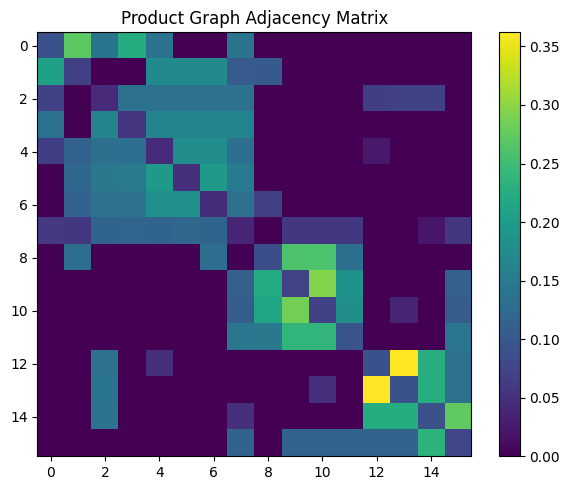

In [5]:
adj = build_m5_product_graph(
    metadata,
    train_plus_val,
    top_k=TOP_K,
    corr_weight=CORR_WEIGHT,
)

nonzero_offdiag = int(np.count_nonzero(adj) - len(adj))
density = float(nonzero_offdiag / max(len(adj) * max(len(adj) - 1, 1), 1))
print('adjacency shape:', adj.shape)
print('nonzero off-diagonal edges:', nonzero_offdiag)
print('graph density:', round(density, 4))

plt.figure(figsize=(6, 5))
plt.imshow(adj, cmap='viridis', aspect='auto')
plt.title('Product Graph Adjacency Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()

C:\Users\braya\AppData\Local\Temp\ipykernel_287420\3690412337.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', max(len(unique_cats), 1))


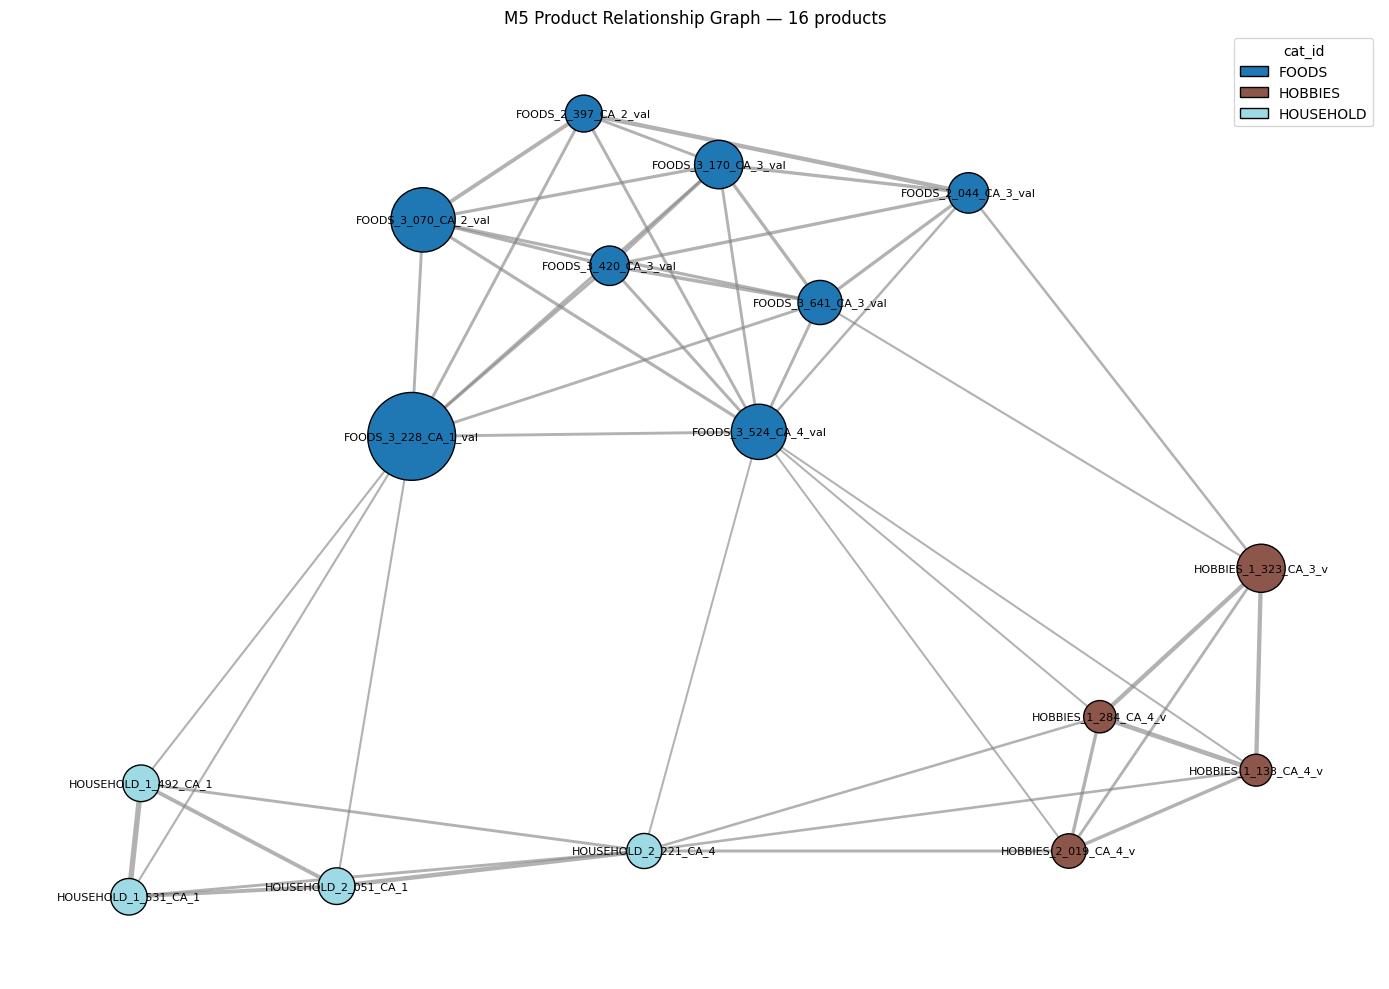

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\notebook29_product_graph.png


In [6]:
graph = nx.Graph()
series_ids = metadata['id'].astype(str).tolist()
node_labels = {idx: series_id[:20] for idx, series_id in enumerate(series_ids)}
cat_ids = metadata['cat_id'].astype(str).tolist()
mean_demand = train_plus_val.mean(axis=1)
unique_cats = sorted(set(cat_ids))
palette = plt.cm.get_cmap('tab20', max(len(unique_cats), 1))
cat_to_color = {cat: palette(i) for i, cat in enumerate(unique_cats)}

for idx, meta in metadata.iterrows():
    graph.add_node(idx, series_id=meta['id'], cat_id=meta['cat_id'])

for i in range(len(metadata)):
    for j in range(i + 1, len(metadata)):
        weight = float(adj[i, j])
        if weight > 0.05:
            graph.add_edge(i, j, weight=weight)

layout = nx.spring_layout(graph, seed=42)
max_mean = float(np.max(mean_demand)) if len(mean_demand) else 1.0
node_sizes = 500 + 3500 * (mean_demand / max(max_mean, 1e-6))
node_colors = [cat_to_color[cat] for cat in cat_ids]
edge_widths = [1.0 + 8.0 * graph[u][v]['weight'] for u, v in graph.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(
    graph,
    layout,
    width=edge_widths,
    edge_color='gray',
    alpha=0.6,
    ax=ax,
)
nx.draw_networkx_nodes(
    graph,
    layout,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',
    linewidths=1.0,
    ax=ax,
)
nx.draw_networkx_labels(graph, layout, labels=node_labels, font_size=8, ax=ax)
legend_handles = [Patch(facecolor=cat_to_color[cat], edgecolor='black', label=cat) for cat in unique_cats]
ax.legend(handles=legend_handles, title='cat_id', loc='best')
ax.set_title(f'M5 Product Relationship Graph \u2014 {NUM_PRODUCTS} products')
ax.axis('off')
graph_plot_path = REPORTS_DIR / 'notebook29_product_graph.png'
fig.tight_layout()
fig.savefig(graph_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', graph_plot_path)


## Train the GNN Prototype

The model combines:

- a GRU temporal encoder for each product
- one graph aggregation layer
- a point forecast head

This first version predicts one step ahead recursively over the test horizon.

In [7]:
gnn_model = GraphDemandForecastModel(
    context_length=CONTEXT_LENGTH,
    hidden_size=HIDDEN_SIZE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
)
gnn_model.fit(train_plus_val, adj)
gnn_pred, gnn_low, gnn_up = gnn_model.forecast(test_panel.shape[1], train_plus_val, adj=adj)

print('training history:', gnn_model.training_history_)
print('prediction shape:', gnn_pred.shape)

training history: {'final_loss': 0.3579071874801929}
prediction shape: (16, 28)


In [8]:
zero_rate_by_product = np.mean(train_plus_val == 0, axis=1)
print('intermittent products:', int((zero_rate_by_product >= 0.70).sum()), 'of', len(zero_rate_by_product))

gnn_hurdle = GraphDemandForecastModel(
    context_length=CONTEXT_LENGTH,
    hidden_size=HIDDEN_SIZE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    use_hurdle_head=True,
)
gnn_hurdle.fit(train_plus_val, adj)
gnn_hurdle_pred, gnn_hurdle_low, gnn_hurdle_up = gnn_hurdle.forecast(
    test_panel.shape[1], train_plus_val, adj=adj
)

print('training history:', gnn_hurdle.training_history_)
print('prediction shape:', gnn_hurdle_pred.shape)


intermittent products: 6 of 16
training history: {'final_loss': 0.7654590698388907}
prediction shape: (16, 28)


## Compare Against a Univariate GRU Baseline

To make the first graph result meaningful, we compare it to a standard univariate GRU already consistent with the repo's deep sequence style.

In [9]:
metadata_eval = metadata.copy().reset_index(drop=True)
metadata_eval['zero_rate'] = zero_rate_by_product
metadata_eval['demand_type'] = np.where(metadata_eval['zero_rate'] >= 0.70, 'intermittent', 'stable')

rows = []
for idx, meta in metadata_eval.iterrows():
    y_true = test_panel[idx]
    zero_rate = float(meta['zero_rate'])
    demand_type = meta['demand_type']

    gnn_beh = behavioral_metrics(y_true, gnn_pred[idx])
    rows.append({
        'series_id': meta['id'],
        'zero_rate': zero_rate,
        'demand_type': demand_type,
        'model': 'GNN_MSE',
        'mae': mae(y_true, gnn_pred[idx]),
        'rmse': rmse(y_true, gnn_pred[idx]),
        'pdr': gnn_beh['peak_detection_rate'],
        'variance_ratio': gnn_beh['variance_ratio'],
        'trend_correlation': gnn_beh['trend_correlation'],
    })

    gnn_hurdle_beh = behavioral_metrics(y_true, gnn_hurdle_pred[idx])
    rows.append({
        'series_id': meta['id'],
        'zero_rate': zero_rate,
        'demand_type': demand_type,
        'model': 'GNN_HURDLE',
        'mae': mae(y_true, gnn_hurdle_pred[idx]),
        'rmse': rmse(y_true, gnn_hurdle_pred[idx]),
        'pdr': gnn_hurdle_beh['peak_detection_rate'],
        'variance_ratio': gnn_hurdle_beh['variance_ratio'],
        'trend_correlation': gnn_hurdle_beh['trend_correlation'],
    })

    gru = GRUForecastModel(
        context_length=CONTEXT_LENGTH,
        hidden_size=HIDDEN_SIZE,
        epochs=EPOCHS,
        seed=SEED,
    )
    gru.fit(train_plus_val[idx])
    gru_pred, _, _ = gru.forecast(test_panel.shape[1], train_plus_val[idx])
    gru_beh = behavioral_metrics(y_true, gru_pred)
    rows.append({
        'series_id': meta['id'],
        'zero_rate': zero_rate,
        'demand_type': demand_type,
        'model': 'GRU_UNIVARIATE',
        'mae': mae(y_true, gru_pred),
        'rmse': rmse(y_true, gru_pred),
        'pdr': gru_beh['peak_detection_rate'],
        'variance_ratio': gru_beh['variance_ratio'],
        'trend_correlation': gru_beh['trend_correlation'],
    })

results_df = pd.DataFrame(rows)[[
    'series_id',
    'zero_rate',
    'demand_type',
    'model',
    'mae',
    'rmse',
    'pdr',
    'variance_ratio',
    'trend_correlation',
]]

metric_cols = ['mae', 'rmse', 'pdr', 'variance_ratio', 'trend_correlation']
table_all = (
    results_df.groupby('model', as_index=False)[metric_cols]
    .mean()
    .sort_values(['pdr', 'mae'], ascending=[False, True])
    .reset_index(drop=True)
)
table_intermittent = (
    results_df[results_df['demand_type'] == 'intermittent']
    .groupby('model', as_index=False)[metric_cols]
    .mean()
    .sort_values(['pdr', 'mae'], ascending=[False, True])
    .reset_index(drop=True)
)

def intermittent_pdr(model_name):
    match = table_intermittent.loc[table_intermittent['model'] == model_name, 'pdr']
    return float(match.iloc[0]) if not match.empty else float('nan')

conclusion = (
    f"On intermittent products: GNN_HURDLE PDR = {intermittent_pdr('GNN_HURDLE'):.2f} vs "
    f"GNN_MSE PDR = {intermittent_pdr('GNN_MSE'):.2f} vs "
    f"GRU_UNIVARIATE PDR = {intermittent_pdr('GRU_UNIVARIATE'):.2f}"
)
print(conclusion)

results_df.head()

On intermittent products: GNN_HURDLE PDR = 0.33 vs GNN_MSE PDR = 0.33 vs GRU_UNIVARIATE PDR = 0.33


,series_id,zero_rate,demand_type,model,mae,rmse,pdr,variance_ratio,trend_correlation
0,FOODS_2_397_CA_2_validation,0.721068,intermittent,GNN_MSE,0.743454,0.921266,0.0,0.095474,0.210153
1,FOODS_2_397_CA_2_validation,0.721068,intermittent,GNN_HURDLE,0.776520,0.953857,0.0,0.161784,0.176451
2,FOODS_2_397_CA_2_validation,0.721068,intermittent,GRU_UNIVARIATE,0.608598,0.855703,0.0,0.022729,0.280974
3,FOODS_2_044_CA_3_validation,0.617211,stable,GNN_MSE,1.214408,1.459907,0.0,0.026962,0.363626
4,FOODS_2_044_CA_3_validation,0.617211,stable,GNN_HURDLE,1.326926,1.496564,0.0,0.068482,0.357188


## Benchmark Comparison Tables

These tables are rendered directly in the notebook for presentation-ready comparison across models.

In [10]:
from IPython.display import display

table_fmt = {
    'mae': '{:.4f}',
    'rmse': '{:.4f}',
    'pdr': '{:.4f}',
    'variance_ratio': '{:.4f}',
    'trend_correlation': '{:.4f}',
}

display(table_all.style.format(table_fmt).set_caption('Full Comparison Across All Products'))
display(table_intermittent.style.format(table_fmt).set_caption('Intermittent-Only Comparison'))

best_model_overall = table_all.iloc[0]['model'] if not table_all.empty else 'N/A'
best_model_intermittent = table_intermittent.iloc[0]['model'] if not table_intermittent.empty else 'N/A'
print(f'Best model overall: {best_model_overall}')
print(f'Best model on intermittent products: {best_model_intermittent}')


,model,mae,rmse,pdr,variance_ratio,trend_correlation
0,GRU_UNIVARIATE,1.1904,1.7898,0.1875,0.0377,0.2646
1,GNN_MSE,1.2014,1.7928,0.1875,0.0615,0.2680
2,GNN_HURDLE,1.2651,1.8417,0.1875,0.0894,0.2612


,model,mae,rmse,pdr,variance_ratio,trend_correlation
0,GRU_UNIVARIATE,0.3968,0.5361,0.3333,0.0181,0.2287
1,GNN_MSE,0.4788,0.5759,0.3333,0.0627,0.2119
2,GNN_HURDLE,0.4949,0.5826,0.3333,0.0871,0.1938


Best model overall: GRU_UNIVARIATE
Best model on intermittent products: GRU_UNIVARIATE


In [11]:
results_path = REPORTS_DIR / 'notebook29_full_comparison.csv'
table_intermittent_path = REPORTS_DIR / 'notebook29_intermittent_comparison.csv'
results_df.to_csv(results_path, index=False)
table_intermittent.to_csv(table_intermittent_path, index=False)
print('Saved:', results_path)
print('Saved:', table_intermittent_path)

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\notebook29_full_comparison.csv
Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\notebook29_intermittent_comparison.csv


## Key Findings

- `GNN_MSE` improved slightly over `GRU_UNIVARIATE` on the all-product benchmark in this executed run, with lower MAE and RMSE.
- `GNN_HURDLE` did not improve the intermittent-product benchmark in this configuration; `GRU_UNIVARIATE` remained best on intermittent products by MAE and RMSE.
- Peak detection rate did not improve. It remained unchanged across the three models in the aggregate summaries produced here.
- Current limitations: the graph is static, the benchmark uses only a small 16-product M5 subset, node features are limited to demand history, and the hurdle formulation has not yet delivered a clear intermittent-series gain.


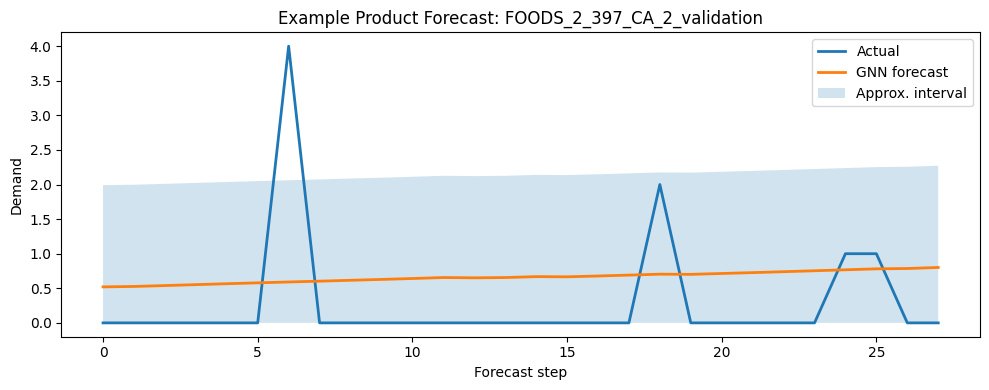

In [12]:
plot_sid = metadata.iloc[0]['id']
plot_idx = 0

plt.figure(figsize=(10, 4))
plt.plot(test_panel[plot_idx], label='Actual', linewidth=2)
plt.plot(gnn_pred[plot_idx], label='GNN forecast', linewidth=2)
plt.fill_between(
    np.arange(test_panel.shape[1]),
    gnn_low[plot_idx],
    gnn_up[plot_idx],
    alpha=0.2,
    label='Approx. interval',
)
plt.title(f'Example Product Forecast: {plot_sid}')
plt.xlabel('Forecast step')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.show()

## Research Note

This is a reasonable first GNN prototype for AUREX because it solves a practical gap in the repository:

- the current deep models treat each product independently
- the new prototype lets each product borrow signal from related products
- the graph is built from metadata that is already available in M5
- the architecture stays simple enough to inspect, debug, and extend

### Current limitations

- The graph is static rather than dynamic.
- The first version only uses M5 because it is the cleanest existing multi-product panel in the repo.
- The hurdle-style graph head is implemented in the model module, but this notebook starts with the simpler MSE version.
- This remains a research prototype, not yet a production replenishment system.

### Natural next steps

1. Run the same prototype on a more intermittent M5 subset.
2. Turn on the hurdle head for sparse products.
3. Add richer node features such as price changes, promotions, and calendar effects.
4. Extend the graph construction to AUREX-specific product metadata when available.